# Football Player Scouting & Recruitment Recommendation System

## 04 — Similarity & Replacement Scouting

This notebook explores player-to-player similarity using cosine similarity.

Two use cases are demonstrated:

### Similar Player Search

Given a target player, identify other players with similar ability profiles.

### Replacement Scouting

Given a target player who may leave a club, identify similar eligible
replacement candidates subject to constraints such as age and position.

In [ ]:
import sys
from pathlib import Path

import pandas as pd

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.features import (
    ABILITY_GROUPS,
    INDIVIDUAL_ABILITIES,
    normalize_attributes,
    create_ability_features,
    ABILITY_FEATURES
)

from src.similarity import (
    find_similar_players,
    find_replacements,
)

In [ ]:
DATA_PATH = PROJECT_ROOT / "data" / "players_cleaned.csv"

df = pd.read_csv(
    DATA_PATH,
    parse_dates=["birthdate"]
)

df_normalized = normalize_attributes(df)
df_normalized = create_ability_features(df_normalized)

ability_features = ABILITY_FEATURES

In [9]:
target_player = df_normalized[
    (
        df_normalized["first_name"] == "Rodrigo"
    )
    &
    (
        df_normalized["last_name"].str.contains(
            "Hernández Cascante",
            case=False,
            na=False
        )
    )
    
][
    [
        "player_id",
        "first_name",
        "last_name",
        "club",
        "position",
        "age"
    ]
]

In [10]:
target_player_id = target_player.iloc[0]["player_id"]

target_player_id

np.int64(231866)

## 1. Player Similarity

The first use case is finding players with a similar attribute profile to the selected player.

The similarity calculation uses cosine distance across the engineered scouting abilities.

For this experiment, we restrict the search to players who are eligible to play CDM.

In [11]:
similar_players = find_similar_players(
    df=df_normalized,
    player_id=target_player_id,
    ability_features=ability_features,
    n_neighbors=10,
    position="CDM"
)

similar_players[
    [
        "first_name",
        "last_name",
        "club",
        "position",
        "age",
        "similarity",
        "position_fit"
    ]
]

,first_name,last_name,club,position,age,similarity,position_fit
0,Ibrahim,Sangaré,Nott'm Forest,CDM,28,99.596885,Primary
1,Martín,Zubimendi Ibáñez,Arsenal,CDM,27,99.580752,Primary
2,Thomas,Partey,Al Shabab,CDM,33,99.571269,Primary
3,Bryan,Cristante,AS Roma,CM,31,99.546521,Alternate
4,Rodrigo,Bentancur,Spurs,CDM,29,99.523739,Primary
5,Aleksandar,Pavlović,FC Bayern München,CDM,22,99.511927,Primary
6,Vitaly,Janelt,Brentford,CDM,28,99.500496,Primary
7,Mats,Wieffer,Brighton,RB,26,99.479578,Alternate
8,Amadou,Onana,Aston Villa,CDM,25,99.421630,Primary
9,Granit,Xhaka,Sunderland,CDM,33,99.409111,Primary


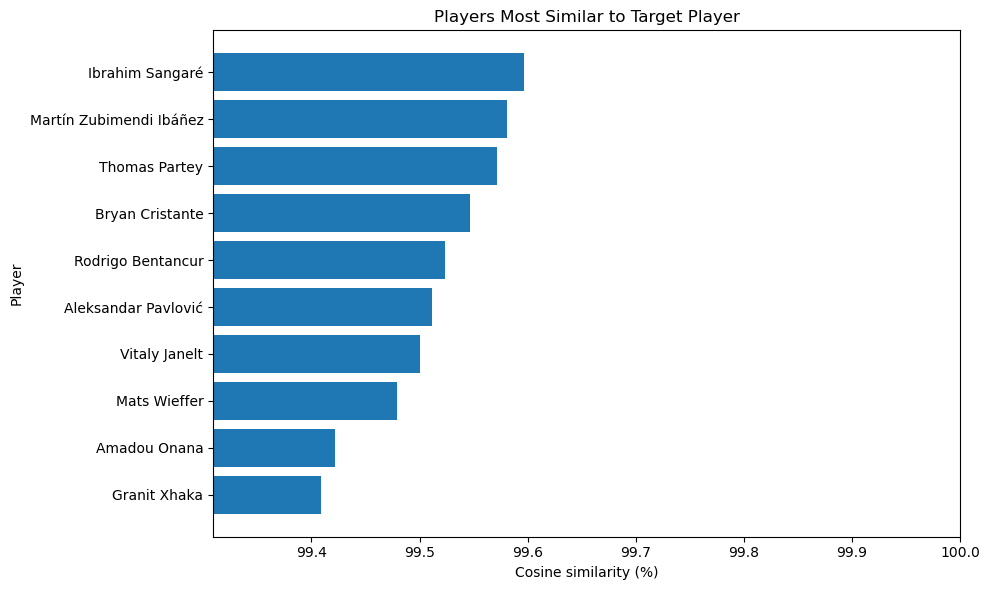

In [13]:
import matplotlib.pyplot as plt

plot_data = similar_players.copy()

plot_data["player_name"] = (
    plot_data["first_name"]
    + " "
    + plot_data["last_name"]
)

plot_data = plot_data.sort_values(
    "similarity"
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_data["player_name"],
    plot_data["similarity"]
)

plt.xlabel("Cosine similarity (%)")
plt.ylabel("Player")
plt.title("Players Most Similar to Target Player")

plt.xlim(
    plot_data["similarity"].min() - 0.1,
    100
)

plt.tight_layout()
plt.show()

### Interpretation

The similarity model identifies players with similar attribute profiles rather than simply players with the highest overall rating.

This makes the method useful when searching for players who could perform a similar role.

However, similarity does not necessarily mean that a player is the best recruitment option. A player can be highly similar while being too old, too expensive, or unsuitable for the club's tactical requirements.

These additional constraints are therefore introduced in the replacement scouting step.

## 2. Replacement Scouting

The second use case is identifying younger replacement candidates for a selected player.

The system:

1. Identifies the target player's position.
2. Filters players who are eligible for that position.
3. Removes the target player.
4. Applies an age constraint.
5. Calculates cosine similarity.
6. Returns the most similar candidates.

In [14]:
replacements = find_replacements(
    df=df_normalized,
    player_id=target_player_id,
    ability_features=ability_features,
    max_age=24,
    position="CDM",
    n_neighbors=10
)

replacements[
    [
        "first_name",
        "last_name",
        "club",
        "position",
        "age",
        "similarity",
        "position_fit"
    ]
]

,first_name,last_name,club,position,age,similarity,position_fit
0,Aleksandar,Pavlović,FC Bayern München,CDM,22,99.511927,Primary
1,Lesley,Ugochukwu,Galatasaray,CDM,22,99.394989,Primary
2,Lena,Oberdorf,FC Bayern München,CDM,24,99.326903,Primary
3,Elliot,Anderson,Manchester City,CDM,23,99.323157,Primary
4,Rafel,Bauzà Sureda,RCD Espanyol,CDM,21,99.318891,Primary
5,Harrison,Armstrong,Everton,CM,19,99.287822,Alternate
6,Oussama,Targhalline,Feyenoord,CDM,24,99.285833,Primary
7,Ryan,Gravenberch,Liverpool,CDM,24,99.280448,Primary
8,Yehor,Yarmoliuk,Brentford,CDM,22,99.272806,Primary
9,Katharina,Piljić,VfL Wolfsburg,CM,23,99.271947,Alternate


In [15]:
replacement_table = replacements[
    [
        "first_name",
        "last_name",
        "club",
        "position",
        "age",
        "similarity",
        "position_fit"
    ]
].copy()

replacement_table["player"] = (
    replacement_table["first_name"]
    + " "
    + replacement_table["last_name"]
)

replacement_table = replacement_table[
    [
        "player",
        "club",
        "position",
        "age",
        "similarity",
        "position_fit"
    ]
]

replacement_table

,player,club,position,age,similarity,position_fit
0,Aleksandar Pavlović,FC Bayern München,CDM,22,99.511927,Primary
1,Lesley Ugochukwu,Galatasaray,CDM,22,99.394989,Primary
2,Lena Oberdorf,FC Bayern München,CDM,24,99.326903,Primary
3,Elliot Anderson,Manchester City,CDM,23,99.323157,Primary
4,Rafel Bauzà Sureda,RCD Espanyol,CDM,21,99.318891,Primary
5,Harrison Armstrong,Everton,CM,19,99.287822,Alternate
6,Oussama Targhalline,Feyenoord,CDM,24,99.285833,Primary
7,Ryan Gravenberch,Liverpool,CDM,24,99.280448,Primary
8,Yehor Yarmoliuk,Brentford,CDM,22,99.272806,Primary
9,Katharina Piljić,VfL Wolfsburg,CM,23,99.271947,Alternate


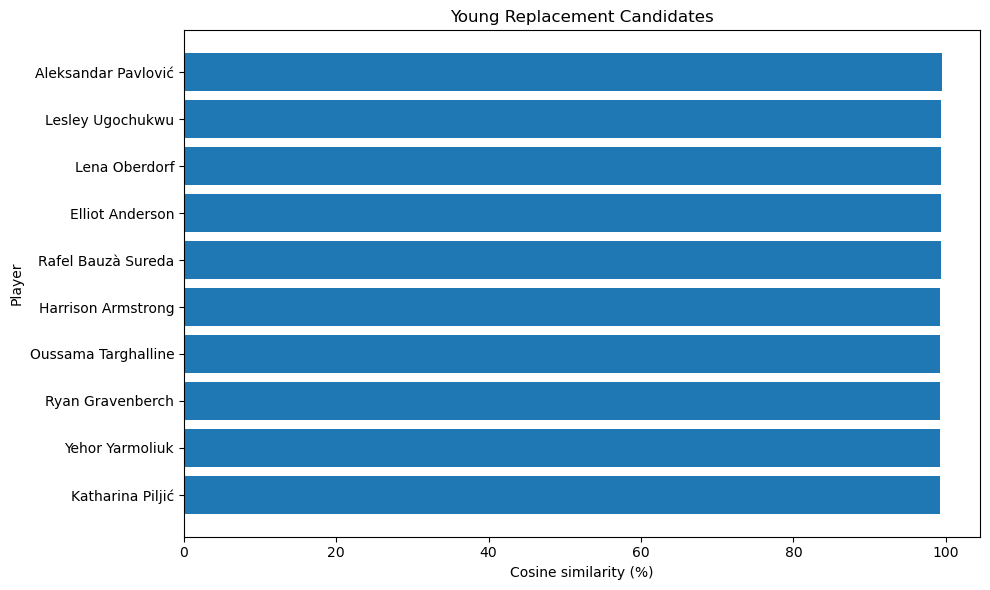

In [16]:
plot_data = replacements.copy()

plot_data["player_name"] = (
    plot_data["first_name"]
    + " "
    + plot_data["last_name"]
)

plot_data = plot_data.sort_values(
    "similarity"
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_data["player_name"],
    plot_data["similarity"]
)

plt.xlabel("Cosine similarity (%)")
plt.ylabel("Player")
plt.title("Young Replacement Candidates")

plt.tight_layout()
plt.show()

## Attribute Profile Comparison

The similarity score tells us how close the players are overall.

To understand *why* a candidate is similar, we compare the engineered scouting abilities of the target and one replacement candidate.

In [17]:
replacement_id = replacements.iloc[0]["player_id"]

target_values = (
    df_normalized[
        df_normalized["player_id"] == target_player_id
    ][ability_features]
    .iloc[0]
)

replacement_values = (
    df_normalized[
        df_normalized["player_id"] == replacement_id
    ][ability_features]
    .iloc[0]
)

comparison = pd.DataFrame({
    "target_player": target_values,
    "replacement": replacement_values
})

comparison

,target_player,replacement
pace,0.567073,0.621951
dribbling_control,0.893137,0.869281
agility,0.499644,0.700569
passing_technique,0.975755,0.878328
shooting_power,0.908390,0.713258
defending,0.929803,0.871305
tackling,0.934003,0.844692
aerial,0.803499,0.761663
physical,0.800560,0.803172
attacking_finishing,0.760870,0.673913


## Conclusions

The similarity-based scouting component provides two complementary capabilities:

### Player similarity

Find players whose overall scouting profiles resemble a selected player.

### Replacement scouting

Extend similarity search with recruitment constraints such as:

- position eligibility
- maximum age
- candidate exclusion

Cosine similarity is appropriate here because the objective is to compare the direction of player ability profiles rather than their absolute magnitude.

The system is intentionally transparent and does not claim to predict real-world player performance.

The dataset is based on FC 27 game attributes, so the recommendations represent similarity within the game's attribute system rather than objective real-world scouting quality.